In [2]:
# =============================================================================
# IMPORT NECESSARY PACKAGES
# =============================================================================
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import pandas as pd
from numba import njit

# =============================================================================
# GLOBAL REPRODUCIBILITY SEED
# Set to an integer for fully reproducible results.
# Set to None for a fresh random run every time.
# =============================================================================
MASTER_SEED = 3247
# MASTER_SEED = None

def _rng(offset=0):
    seed = None if MASTER_SEED is None else MASTER_SEED + offset
    return np.random.default_rng(seed)

### Simulator Code

#### Default Simulator

I just left this here to reference the logic. It is not used in the simulator and is here purely for legacy reasons. 

In [3]:
"""
Adaptive-network SIR epidemic simulator.

This module simulates an SIR (Susceptible-Infected-Recovered) epidemic
spreading on a network that evolves over time. The key idea is that
susceptible individuals can "rewire" their connections to avoid infected
neighbors, which couples the disease dynamics with the network topology.

The model proceeds in discrete time steps, each with three phases:
  1. Infection: infected nodes transmit the disease to susceptible neighbors
  2. Recovery: infected nodes recover (and become immune)
  3. Rewiring: susceptible nodes break links with infected neighbors and
     form new connections elsewhere

Reference: Gross et al. (2006), "Epidemic dynamics on an adaptive network",
Physical Review Letters, 96(20), 208701.
"""

def simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, rng=None):
    """Run one replicate of the adaptive-network SIR model.

    Parameters
    ----------
    beta : float in [0, 1]
        Transmission probability. At each time step, each S-I edge
        transmits the infection independently with probability beta.
        Higher beta means the disease spreads faster.
    gamma : float in [0, 1]
        Recovery probability. At each time step, each infected node
        recovers independently with probability gamma.
        Higher gamma means shorter infectious period (on average 1/gamma steps).
    rho : float in [0, 1]
        Rewiring probability. At each time step, each S-I edge is
        rewired independently with probability rho. The susceptible
        node drops the link to its infected neighbor and connects to
        a randomly chosen new node instead.
        Higher rho means more active social distancing behavior.
    N : int, default=200
        Number of nodes (individuals) in the network.
    p_edge : float, default=0.05
        Probability of an edge between any two nodes in the initial
        Erdos-Renyi random graph. Expected initial degree is (N-1)*p_edge.
        With N=200 and p_edge=0.05, the expected degree is about 10.
    n_infected0 : int, default=5
        Number of nodes infected at time t=0. These are chosen
        uniformly at random (without replacement) from all N nodes.
    T : int, default=200
        Number of discrete time steps to simulate.
    rng : numpy.random.Generator or None
        Random number generator for reproducibility. If None, a new
        generator is created with an arbitrary seed. Pass
        np.random.default_rng(seed) for reproducible runs.

    Returns
    -------
    infected_fraction : np.ndarray, shape (T+1,)
        Fraction of the population that is infected at each time step,
        from t=0 to t=T. Values are in [0, 1].
    rewire_counts : np.ndarray, shape (T+1,)
        Number of successful rewiring events at each time step.
        Always 0 at t=0 (no rewiring before the simulation starts).
    degree_histogram : np.ndarray, shape (31,)
        Histogram of node degrees at the final time step t=T.
        degree_histogram[d] = number of nodes with degree d, for d=0..29.
        degree_histogram[30] counts all nodes with degree >= 30.
    """
    if rng is None:
        rng = np.random.default_rng()

    # =====================================================================
    # STEP 0: Build the initial contact network as an Erdos-Renyi graph.
    #
    # We represent the network as an adjacency list using Python sets.
    # neighbors[i] is the set of node indices connected to node i.
    # Sets allow O(1) lookups for "is j a neighbor of i?" and efficient
    # add/remove operations, which is important for the rewiring step.
    #
    # For each pair (i, j) with i < j, we add an edge with probability
    # p_edge. This produces an undirected graph (if i is connected to j,
    # then j is also connected to i).
    # =====================================================================
    neighbors = [set() for _ in range(N)]
    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() < p_edge:
                neighbors[i].add(j)
                neighbors[j].add(i)

    # =====================================================================
    # Initialize the health state of each node.
    #
    # We encode states as integers:
    #   0 = Susceptible (S): can catch the disease
    #   1 = Infected (I):    currently infectious
    #   2 = Recovered (R):   immune, cannot be infected again
    #
    # At t=0, we pick n_infected0 nodes uniformly at random to be infected.
    # All other nodes start as susceptible.
    # =====================================================================
    state = np.zeros(N, dtype=np.int8)
    initial_infected = rng.choice(N, size=n_infected0, replace=False)
    state[initial_infected] = 1

    # Arrays to record the summary statistics at each time step
    infected_fraction = np.zeros(T + 1)
    rewire_counts = np.zeros(T + 1, dtype=np.int64)
    infected_fraction[0] = np.sum(state == 1) / N

    # =================================================================
    # Main simulation loop: iterate over T discrete time steps.
    # Each time step has three phases applied in order:
    #   Phase 1: Infection (S -> I transitions)
    #   Phase 2: Recovery  (I -> R transitions)
    #   Phase 3: Rewiring  (network topology changes)
    # =================================================================
    for t in range(1, T + 1):

        # =============================================================
        # PHASE 1: INFECTION (synchronous update)
        #
        # For every infected node i, look at each of its neighbors j.
        # If j is susceptible (state 0), the infection transmits with
        # probability beta.
        #
        # Important: we use synchronous (parallel) updating. We first
        # collect ALL new infections in a set, then apply them all at
        # once. This prevents "chain infections" within a single step
        # (where a newly infected node immediately infects its own
        # neighbors in the same step).
        # =============================================================
        new_infections = set()
        infected_nodes = np.where(state == 1)[0]

        for i in infected_nodes:
            for j in neighbors[i]:
                if state[j] == 0:  # j is susceptible
                    if rng.random() < beta:
                        new_infections.add(j)

        # Apply all new infections at once (synchronous update)
        for j in new_infections:
            state[j] = 1

        # =============================================================
        # PHASE 2: RECOVERY
        #
        # Each currently infected node (including those just infected
        # in Phase 1) recovers independently with probability gamma.
        # Recovery is permanent: recovered nodes move to state 2 (R)
        # and can never be infected again.
        #
        # We recompute the infected set to include newly infected nodes.
        # =============================================================
        infected_nodes = np.where(state == 1)[0]
        for i in infected_nodes:
            if rng.random() < gamma:
                state[i] = 2

        # =============================================================
        # PHASE 3: NETWORK REWIRING (adaptive behavior)
        #
        # This is what makes the model "adaptive": the network structure
        # changes in response to the disease.
        #
        # We look at all edges between a susceptible node (S) and an
        # infected node (I), called "S-I edges". For each such edge,
        # with probability rho, the susceptible node:
        #   1. Drops the connection to its infected neighbor
        #   2. Forms a new connection to a randomly chosen other node
        #      (that it is not already connected to)
        #
        # This models social distancing: susceptible individuals
        # actively avoid infected contacts.
        # =============================================================
        rewire_count = 0

        # First, collect all S-I edges. We iterate over susceptible
        # nodes and check their neighbors for infected ones.
        si_edges = []
        for i in range(N):
            if state[i] == 0:  # node i is susceptible
                for j in neighbors[i]:
                    if state[j] == 1:  # neighbor j is infected
                        si_edges.append((i, j))

        # Process each S-I edge for potential rewiring
        for s_node, i_node in si_edges:
            if rng.random() < rho:
                # Check that this edge still exists. An earlier rewiring
                # in this same loop may have already removed it (since
                # rewiring can affect shared neighborhoods).
                if i_node not in neighbors[s_node]:
                    continue

                # Remove the S-I edge (break the link in both directions)
                neighbors[s_node].discard(i_node)
                neighbors[i_node].discard(s_node)

                # Find all valid candidates for a new connection:
                # any node that is not s_node itself and not already
                # a neighbor of s_node. Note that the new partner can
                # be in any state (S, I, or R).
                candidates = []
                for k in range(N):
                    if k != s_node and k not in neighbors[s_node]:
                        candidates.append(k)

                # If there is at least one valid candidate, pick one
                # uniformly at random and create the new edge
                if candidates:
                    new_partner = rng.choice(candidates)
                    neighbors[s_node].add(new_partner)
                    neighbors[new_partner].add(s_node)
                    rewire_count += 1

        # Record summary statistics for this time step
        infected_fraction[t] = np.sum(state == 1) / N
        rewire_counts[t] = rewire_count

    # =====================================================================
    # Compute the degree histogram at the final time step.
    #
    # The degree of a node is its number of connections (neighbors).
    # We bin degrees from 0 to 29 individually, and lump all degrees >= 30
    # into a single bin (index 30). This gives a fixed-size output array
    # of shape (31,) regardless of the actual degree distribution.
    # =====================================================================
    degree_histogram = np.zeros(31, dtype=np.int64)
    for i in range(N):
        deg = min(len(neighbors[i]), 30)
        degree_histogram[deg] += 1

    return infected_fraction, rewire_counts, degree_histogram


#### Numba Simulator (Claude + GPT)

Initially I prompted both ChatGPT and Claude to rewrite the simulator code with Numba to speed it up. ChatGPT's code was 6x faster than Claude's! However after some validating, the rewiring logic for the ChatGPT code was flawed and could potentially lead to an infinite loop. So I decided to put the Chat's code through Claude to fix the rewiring logic and this is the final product. It runs 10k simulations in ~15s and its logic is faithful to the original simulator.

In [ ]:
@njit(cache=True)
def simulate_numba(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200):
    """
    Parameters
    ----------
    beta : float in [0, 1]
        Transmission probability. At each time step, each S-I edge
        transmits the infection independently with probability beta.
        Higher beta means the disease spreads faster.
    gamma : float in [0, 1]
        Recovery probability. At each time step, each infected node
        recovers independently with probability gamma.
        Higher gamma means shorter infectious period (on average 1/gamma steps).
    rho : float in [0, 1]
        Rewiring probability. At each time step, each S-I edge is
        rewired independently with probability rho. The susceptible
        node drops the link to its infected neighbor and connects to
        a randomly chosen new node instead.
        Higher rho means more active social distancing behavior.
    N : int, default=200
        Number of nodes (individuals) in the network.
    p_edge : float, default=0.05
        Probability of an edge between any two nodes in the initial
        Erdos-Renyi random graph. Expected initial degree is (N-1)*p_edge.
        With N=200 and p_edge=0.05, the expected degree is about 10.
    n_infected0 : int, default=5
        Number of nodes infected at time t=0. These are chosen
        uniformly at random (without replacement) from all N nodes.
    T : int, default=200
        Number of discrete time steps to simulate.
    rng : numpy.random.Generator or None
        Random number generator for reproducibility. If None, a new
        generator is created with an arbitrary seed. Pass
        np.random.default_rng(seed) for reproducible runs.

    Returns
    -------
    infected_fraction : np.ndarray, shape (T+1,)
        Fraction of the population that is infected at each time step,
        from t=0 to t=T. Values are in [0, 1].
    rewire_counts : np.ndarray, shape (T+1,)
        Number of successful rewiring events at each time step.
        Always 0 at t=0 (no rewiring before the simulation starts).
    degree_histogram : np.ndarray, shape (31,)
        Histogram of node degrees at the final time step t=T.
        degree_histogram[d] = number of nodes with degree d, for d=0..29.
        degree_histogram[30] counts all nodes with degree >= 30.
    """ 
    # =========================================================================
    # STEP 0: Build the initial Erdos-Renyi contact network.
    #
    # Original (simulator.py lines 85-90):
    #   neighbors = [set() for _ in range(N)]
    #   for i in range(N):
    #       for j in range(i + 1, N):
    #           if rng.random() < p_edge:
    #               neighbors[i].add(j)
    #               neighbors[j].add(i)
    #
    # Here we use a dense boolean adjacency matrix A[i,j] instead of
    # adjacency sets. The graph logic is identical: iterate over all
    # pairs (i,j) with i < j and add an undirected edge with probability
    # p_edge. A[i,j] == 1 is the matrix equivalent of "j in neighbors[i]".
    # =========================================================================
    A = np.zeros((N, N), dtype=np.int8)
    for i in range(N):
        for j in range(i + 1, N):
            if np.random.random() < p_edge:
                A[i, j] = 1
                A[j, i] = 1

    # =========================================================================
    # STEP 0 (cont.): Initialise node states and seed the epidemic.
    #
    # Original (simulator.py lines 103-110):
    #   state = np.zeros(N, dtype=np.int8)
    #   initial_infected = rng.choice(N, size=n_infected0, replace=False)
    #   state[initial_infected] = 1
    #   infected_fraction[0] = np.sum(state == 1) / N
    #
    # State encoding is identical: 0 = S, 1 = I, 2 = R.
    # n_infected0 nodes chosen uniformly at random (without replacement).
    # =========================================================================
    state = np.zeros(N, dtype=np.int8)
    for idx in np.random.choice(N, n_infected0, replace=False):
        state[idx] = 1

    infected_fraction = np.zeros(T + 1)
    rewire_counts     = np.zeros(T + 1)
    infected_fraction[0] = np.sum(state == 1) / N

    # Pre-allocate scratch arrays for Phase 3 (avoids heap allocation inside
    # the hot loop). Maximum possible S-I edges is N*N; N candidates is N.
    si_s       = np.empty(N * N, dtype=np.int32)
    si_i       = np.empty(N * N, dtype=np.int32)
    candidates = np.empty(N,     dtype=np.int32)

    # =========================================================================
    # MAIN LOOP over T discrete time steps.
    #
    # Original (simulator.py lines 119-221):
    #   for t in range(1, T + 1):
    #       <Phase 1: Infection>
    #       <Phase 2: Recovery>
    #       <Phase 3: Rewiring>
    # =========================================================================
    for t in range(1, T + 1):

        # =====================================================================
        # PHASE 1: INFECTION — synchronous update.
        #
        # Original (simulator.py lines 134-145):
        #   new_infections = set()
        #   infected_nodes = np.where(state == 1)[0]
        #   for i in infected_nodes:
        #       for j in neighbors[i]:
        #           if state[j] == 0:
        #               if rng.random() < beta:
        #                   new_infections.add(j)
        #   for j in new_infections:
        #       state[j] = 1
        #
        # new_state.copy() plays the same role as the `new_infections` set:
        # all transmission attempts are evaluated against the state at the
        # START of the step, and infections are written only after all checks
        # are done. This prevents chain-infection within a single step.
        # =====================================================================
        new_state = state.copy()
        for i in range(N):
            if state[i] == 1:                        # node i is infected
                for j in range(N):
                    if A[i, j] == 1 and state[j] == 0:   # j is a susceptible neighbour
                        if np.random.random() < beta:
                            new_state[j] = 1         # queue infection; don't apply yet
        state = new_state                            # apply all infections at once

        # =====================================================================
        # PHASE 2: RECOVERY.
        #
        # Original (simulator.py lines 157-160):
        #   infected_nodes = np.where(state == 1)[0]
        #   for i in infected_nodes:
        #       if rng.random() < gamma:
        #           state[i] = 2
        #
        # Iterates over the UPDATED state (includes nodes just infected in
        # Phase 1). Each infected node recovers independently with prob gamma.
        # Recovery is permanent (state 2 is absorbing).
        # =====================================================================
        for i in range(N):
            if state[i] == 1:
                if np.random.random() < gamma:
                    state[i] = 2

        # =====================================================================
        # PHASE 3: REWIRING — snapshot then process.
        #
        # The original does this in two clearly separated stages:
        #
        # Stage A — collect all S-I edges into a list BEFORE modifying anything
        # (simulator.py lines 182-187):
        #   si_edges = []
        #   for i in range(N):
        #       if state[i] == 0:
        #           for j in neighbors[i]:
        #               if state[j] == 1:
        #                   si_edges.append((i, j))
        #
        # We do the same but write into pre-allocated arrays si_s / si_i
        # (faster than Python list appending inside @njit).
        # =====================================================================
        n_si = 0
        for i in range(N):
            if state[i] == 0:                        # node i is susceptible
                for j in range(N):
                    if A[i, j] == 1 and state[j] == 1:   # j is an infected neighbour
                        si_s[n_si] = i
                        si_i[n_si] = j
                        n_si += 1

        # =====================================================================
        # Stage B — process each snapshotted S-I edge for potential rewiring.
        #
        # Original (simulator.py lines 190-217):
        #   for s_node, i_node in si_edges:
        #       if rng.random() < rho:
        #           if i_node not in neighbors[s_node]:   # <-- stale-edge guard
        #               continue
        #           neighbors[s_node].discard(i_node)
        #           neighbors[i_node].discard(s_node)
        #           candidates = [k for k in range(N)
        #                         if k != s_node and k not in neighbors[s_node]]
        #           if candidates:                        # <-- empty-graph guard
        #               new_partner = rng.choice(candidates)
        #               neighbors[s_node].add(new_partner)
        #               neighbors[new_partner].add(s_node)
        #               rewire_count += 1
        # =====================================================================
        rewire_count = 0
        for e in range(n_si):
            s_node = si_s[e]
            i_node = si_i[e]

            if np.random.random() < rho:

                # -------------------------------------------------------------
                # Stale-edge guard (simulator.py line 195):
                #   if i_node not in neighbors[s_node]: continue
                #
                # An earlier iteration may have already rewired this edge away
                # (because rewiring one S-I edge can affect another susceptible
                # node's neighbourhood). Without this check we would try to
                # remove an edge that no longer exists.
                # -------------------------------------------------------------
                if A[s_node, i_node] == 0:
                    continue

                # Remove the S-I edge in both directions
                # (simulator.py lines 199-200):
                #   neighbors[s_node].discard(i_node)
                #   neighbors[i_node].discard(s_node)
                A[s_node, i_node] = 0
                A[i_node, s_node] = 0

                # -------------------------------------------------------------
                # Build the candidate list (simulator.py lines 206-209):
                #   candidates = [k for k in range(N)
                #                 if k != s_node and k not in neighbors[s_node]]
                #
                # Valid new partners are any node that is:
                #   (a) not s_node itself, and
                #   (b) not already a neighbour of s_node.
                # The new partner may be in any state (S, I, or R) — same as
                # the original which places no state restriction on candidates.
                # -------------------------------------------------------------
                n_cand = 0
                for k in range(N):
                    if k != s_node and A[s_node, k] == 0:
                        candidates[n_cand] = k
                        n_cand += 1

                # -------------------------------------------------------------
                # Empty-graph guard (simulator.py line 213):
                #   if candidates:
                #
                # Only rewire (and only increment the counter) if at least one
                # valid candidate exists. Matches the original exactly.
                # -------------------------------------------------------------
                if n_cand > 0:
                    new_partner = candidates[np.random.randint(0, n_cand)]
                    A[s_node, new_partner] = 1
                    A[new_partner, s_node] = 1
                    rewire_count += 1

        # Record summary statistics for this time step
        # (simulator.py lines 220-221)
        infected_fraction[t] = np.sum(state == 1) / N
        rewire_counts[t]     = rewire_count

    # =========================================================================
    # Compute the degree histogram at the final time step.
    #
    # Original (simulator.py lines 231-234):
    #   for i in range(N):
    #       deg = min(len(neighbors[i]), 30)
    #       degree_histogram[deg] += 1
    #
    # Degrees 0-29 get their own bin; anything >= 30 goes into bin 30.
    # =========================================================================
    degree_histogram = np.zeros(31)
    for i in range(N):
        deg = 0
        for j in range(N):
            deg += A[i, j]
        degree_histogram[min(deg, 30)] += 1

    return infected_fraction, rewire_counts, degree_histogram

# =============================================================================
# JIT warmup — compiles the function once and caches it to disk.
# Subsequent imports skip compilation entirely.
# =============================================================================
def _warmup():
    simulate_numba(0.2, 0.09, 0.35, N=200, T=5)

_warmup()

# =============================================================================
# Setting seed in numba environment
# =============================================================================
@njit(cache=True)
def _seed_numba(seed):
    np.random.seed(seed)

def simulate(beta, gamma, rho, N=200, p_edge=0.05, n_infected0=5, T=200, seed=None):
    if seed is not None:
        _seed_numba(seed)
    return simulate_numba(beta, gamma, rho, N, p_edge, n_infected0, T)

### Simple Rejection ABC (Claude)

#### Loading observed data and observed summary statistics

The six statistics used for ABC inference are defined below. All are 
computed by `compute_all_stats()` and selected via `STAT_COLS`.

<div align="center">

| Statistic | Definition |
|---|---|
| `peak` | maximum infection proportion|
| `peak_t` | time of maximum infection proporrtion |
| `auc` | area under infection curve |
| `peak_rew` | maximum rewiring counts |
| `rew_per_infected` | total number of rewirings divided by total infection proportion |
| `var_deg` | variance of final degree distribution |
</div>

`compute_all_stats()` computes a wider set of 14 candidate statistics. 
The remaining candidate statistics are described as below. 
To experiment with different subsets, simply change `STAT_COLS` — no 
re-simulation is needed as all statistics are pre-computed and stored in `sim_df`.

<div align="center">

| Statistic | Definition |
|---|---|
| `early` | initial growth rate of infection|
| `late` | decay in infection after peak |
| `duration` | duration of epidemic (Baseline: infection prop > 0.01) |
| `total_rew` | total rewiring counts |
| `peak_rew_t` | time of maximum rewiring counts |
| `rew_peak_lag` | difference in time of max infection and max rewiring |
| `mean_deg` | mean of final degree distribution |
| `low_deg` | counts of deg $\leq 5$ in degree distribution|
</div>


In [ ]:
# ── Load observed data ────────────────────────────────────────────────────────
inf_df = pd.read_csv('infected_timeseries.csv')
rew_df = pd.read_csv('rewiring_timeseries.csv')
deg_df = pd.read_csv('final_degree_histograms.csv')
for df in (inf_df, rew_df, deg_df):
    df.columns = df.columns.str.strip()

N_NODES = 200


def compute_all_stats(inf, rew, deg_degrees, deg_counts):
    """
    Compute all 14 candidate summary statistics from one simulation.

    Statistics are grouped into three categories:
      - Infection dynamics: peak, peak_t, auc, early, late, duration
      - Rewiring dynamics: total_rew, peak_rew, peak_rew_t
      - Coupling / network: rew_peak_lag, rew_per_infected, mean_deg, var_deg, low_deg

    The active subset for inference is selected via STAT_COLS (ABC)
    or BSL_STAT_COLS (BSL). All statistics are always computed so that
    STAT_COLS can be changed without re-running the simulator.

    Parameters
    ----------
    inf         : np.ndarray, shape (T+1,) — infected fraction time series
    rew         : np.ndarray, shape (T+1,) — rewiring count time series
    deg_degrees : np.ndarray — degree values (0..30)
    deg_counts  : np.ndarray — count of nodes at each degree

    Returns
    -------
    dict of float — all 14 named statistics
    """
    T = len(inf)

    # ─────────────────────────────────────────────
    # Infection dynamics
    # ─────────────────────────────────────────────
    peak = float(inf.max())
    peak_t = int(np.argmax(inf))
    auc = float(np.trapezoid(inf))

    # Early growth to capture (beta - gamma)
    log_inf = np.log(inf[1:11] + 1e-9) 
    early = float(np.polyfit(np.arange(1, 11), log_inf, 1)[0])

    # Late decay (20 steps after peak)
    if peak_t < T - 20:
        late = float(np.polyfit(np.arange(20), inf[peak_t:peak_t+20], 1)[0])
    else:
        tail = inf[peak_t:]
        late = float(np.polyfit(np.arange(len(tail)), tail, 1)[0]) if len(tail) >= 2 else 0.0

    # Duration above small threshold
    duration = float(np.sum(inf > 0.01))

    # ─────────────────────────────────────────────
    # Rewiring dynamics
    # ─────────────────────────────────────────────
    total_rew = float(rew.sum())
    peak_rew = float(rew.max())
    peak_rew_t = int(np.argmax(rew))

    # ─────────────────────────────────────────────
    # Coupling infection–rewiring
    # ─────────────────────────────────────────────
    rew_peak_lag = float(peak_rew_t - peak_t)
    rew_per_infected = float(total_rew / (np.sum(inf) + 1e-8))

    # ─────────────────────────────────────────────
    # Network structure (using degrees and counts)
    # ─────────────────────────────────────────────
    # We use N_NODES (200) as the denominator for mean/variance
    mean_deg = float(np.dot(deg_degrees, deg_counts) / N_NODES)
    var_deg = float(np.dot((deg_degrees - mean_deg) ** 2, deg_counts) / N_NODES)
    low_deg = float(np.sum(deg_counts[:6]))  # degree ≤ 5

    return dict(
        peak=peak, peak_t=peak_t, auc=auc, early=early, late=late, duration=duration,
        total_rew=total_rew, peak_rew=peak_rew, peak_rew_t=peak_rew_t,
        rew_peak_lag=rew_peak_lag, rew_per_infected=rew_per_infected,
        mean_deg=mean_deg, var_deg=var_deg, low_deg=low_deg
    )

# ── Compute S_obs from the 40 observed replicates ────────────────────────────
obs_rows = []
for rep in sorted(inf_df['replicate_id'].unique()):
    inf = inf_df[inf_df['replicate_id'] == rep].sort_values('time')['infected_fraction'].values
    rew = rew_df[rew_df['replicate_id'] == rep].sort_values('time')['rewire_count'].values
    deg_row = deg_df[deg_df['replicate_id'] == rep].sort_values('degree')
    obs_rows.append(compute_all_stats(
        inf, rew, deg_row['degree'].values, deg_row['count'].values
    ))

obs_mat_df = pd.DataFrame(obs_rows)
S_obs_full = obs_mat_df.mean()
S_obs_std  = obs_mat_df.std(ddof=1)

print("S_obs (mean ± std across 40 replicates):")
for col in obs_mat_df.columns:
    print(f"  {col:>16s}: {S_obs_full[col]:>10.4f}  ±  {S_obs_std[col]:.4f}")

S_obs (mean ± std across 40 replicates):
              peak:     0.6571  ±  0.0427
            peak_t:     8.7500  ±  1.1929
               auc:    11.3865  ±  0.8785
             early:     0.2652  ±  0.0313
              late:    -0.0276  ±  0.0024
          duration:    57.5500  ±  7.5139
         total_rew:   545.1500  ±  38.6248
          peak_rew:    98.1250  ±  10.2111
        peak_rew_t:     5.5000  ±  1.2810
      rew_peak_lag:    -3.2500  ±  0.8397
  rew_per_infected:    48.0936  ±  4.9956
          mean_deg:    10.0172  ±  0.3209
           var_deg:    10.3410  ±  1.2410
           low_deg:    13.8750  ±  4.2438


#### Build reference table for ABC

This code is computationally expensive, but you only need to run it once. On average it takes 25min for 1 million simulations. 

In [ ]:
# Edit N_sims to alter the number of total simulations
N_sims = 1_000_000

N_interval = N_sims / 10
abc_rng = _rng(2473)
param_seeds = abc_rng.integers(0, 2**31, size=N_sims)
print(f"\nRunning {N_sims} simulations. This may take a while...")

rows = []
for i in range(N_sims):
    b = abc_rng.uniform(0.05, 0.50)
    g = abc_rng.uniform(0.02, 0.20)
    r = abc_rng.uniform(0.00, 0.80)

    inf, rew, deg_hist = simulate(b, g, r, seed=int(param_seeds[i]))
    sum_stats = compute_all_stats(inf, rew, np.arange(31), deg_hist)
    sum_stats.update(beta=b, gamma=g, rho=r)
    rows.append(sum_stats)

    if (i + 1) % N_interval == 0:
        print(f"Completed {i + 1} / {N_sims} simulations")

sim_df = pd.DataFrame(rows)
print(f"\nDone. sim_df shape: {sim_df.shape}")
print("Columns:", list(sim_df.columns))


Running 1000000 simulations. This may take a while...
Completed 100000 / 1000000 simulations
Completed 200000 / 1000000 simulations
Completed 300000 / 1000000 simulations
Completed 400000 / 1000000 simulations
Completed 500000 / 1000000 simulations
Completed 600000 / 1000000 simulations
Completed 700000 / 1000000 simulations
Completed 800000 / 1000000 simulations
Completed 900000 / 1000000 simulations
Completed 1000000 / 1000000 simulations

Done. sim_df shape: (1000000, 17)
Columns: ['peak', 'peak_t', 'auc', 'early', 'late', 'duration', 'total_rew', 'peak_rew', 'peak_rew_t', 'rew_peak_lag', 'rew_per_infected', 'mean_deg', 'var_deg', 'low_deg', 'beta', 'gamma', 'rho']


#### Distance computation and ABC acceptance

**To change the summary statistic set:** modify `STAT_COLS` below and re-run 
from this cell — no re-simulation required, as all statistics are already 
stored in `sim_df`.

**Alternative distance metrics** (commented out below `STAT_COLS`):
- **Euclidean (default):** fast, simple, no additional assumptions
- **Mahalanobis (uncomment lines below):** accounts for the covariance 
  structure of the summary statistics, giving more weight to 
  discriminative directions. Uncomment the Mahalanobis block to use it.

**Regression adjustment** (Beaumont et al. 2002, also commented out): 
post-processing correction that shrinks accepted samples toward the 
observed summaries via local linear regression. Uncomment the regression 
block to apply it to the accepted posterior without re-running the simulator.

In [17]:
# Possible Columns
# ['peak', 'peak_t', 'auc', 'early', 'late', 'duration', 
# 'total_rew', 'peak_rew', 'peak_rew_t', 'rew_peak_lag', 'rew_per_infected', 
# 'mean_deg', 'var_deg', 'low_deg']

STAT_COLS = ['peak', 'peak_t', 'auc', 'peak_rew', 'rew_per_infected', 'var_deg']
# STAT_COLS = ['peak', 'peak_t', 'auc', 'peak_rew', 'total_rew', 'var_deg'] 
# STAT_COLS = ['peak', 'peak_t', 'auc', 'early', 'duration']

# ── Normalise and compute Euclidean distances ─────────────────────────────────
S_obs_vec = S_obs_full[STAT_COLS].values

sim_stats = sim_df[STAT_COLS].values
sim_mean  = sim_stats.mean(axis=0)
sim_std   = sim_stats.std(axis=0)
sim_std[sim_std == 0] = 1e-6

S_sim_norm = (sim_stats  - sim_mean) / sim_std
S_obs_norm = (S_obs_vec  - sim_mean) / sim_std

distances = np.linalg.norm(S_sim_norm - S_obs_norm, axis=1)
sim_df['distance'] = distances

# ── Compute Mahalanobis distance ─────────────────────────────────────────────
# Uncomment this block (and comment out the Euclidean block above) to use
# Mahalanobis distance instead. Accounts for correlations between summaries.

# S_obs_vec = S_obs_full[STAT_COLS].values
# sim_stats = sim_df[STAT_COLS].values

# # Estimate covariance of summaries
# Sigma = np.cov(sim_stats, rowvar=False)

# # Regularisation for numerical stability
# ridge = 1e-6 * np.eye(Sigma.shape[0])
# Sigma_inv = np.linalg.inv(Sigma + ridge)

# # Compute Mahalanobis distances
# diff = sim_stats - S_obs_vec
# distances = np.sqrt(np.einsum('ij,jk,ik->i', diff, Sigma_inv, diff))

# sim_df['distance'] = distances

# ── Accept top 1 % ───────────────────────────────────────────────────────────
ACCEPTANCE_RATE = 0.01
epsilon = np.quantile(distances, ACCEPTANCE_RATE)
posterior = sim_df[sim_df['distance'] <= epsilon].copy()

# ── Regression adjustment (Beaumont et al. 2002) ─────────────────────────────
# Uncomment to apply local linear regression post-processing to the ABC
# posterior. Sharpens estimates by reducing bias and allowing a larger epsilon.

# ACCEPTANCE_RATE = 0.10
# epsilon = np.quantile(distances, ACCEPTANCE_RATE)

# accepted = sim_df[sim_df['distance'] <= epsilon].copy()

# # Standardised summary stats (global scaling — correct)
# S_acc = (accepted[STAT_COLS].values - sim_mean) / sim_std
# S_obs = (S_obs_vec - sim_mean) / sim_std

# delta_s = S_acc - S_obs

# posterior = accepted[['beta', 'gamma', 'rho']].copy()

# for param in ['beta', 'gamma', 'rho']:

#     theta = accepted[param].values

#     # Design matrix: intercept + summary deviations
#     X = np.column_stack([np.ones(len(theta)), delta_s])

#     # Ordinary least squares
#     beta_hat = np.linalg.lstsq(X, theta, rcond=None)[0]

#     # Adjustment
#     theta_adj = theta - (X @ beta_hat - beta_hat[0])

#     posterior[param] = theta_adj

#### Posterior summary and plots

Statistics used:  ['peak', 'peak_t', 'auc', 'peak_rew', 'rew_per_infected', 'var_deg']
Accepted:         10,000 / 1,000,000  (ε = 0.6612)

 param       mean        std         95% CI           contraction
----------------------------------------------------------------------
   beta     0.1770     0.0382   [0.1123, 0.2578]         67.7%
  gamma     0.0881     0.0160   [0.0613, 0.1214]         66.6%
    rho     0.3051     0.0624   [0.1940, 0.4299]         70.5%


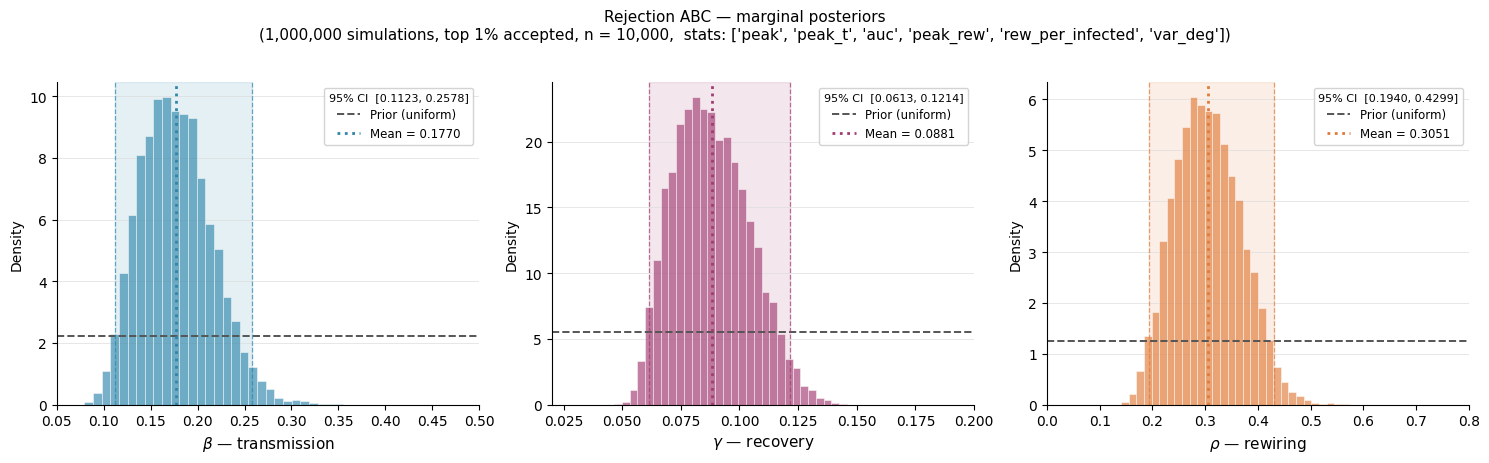

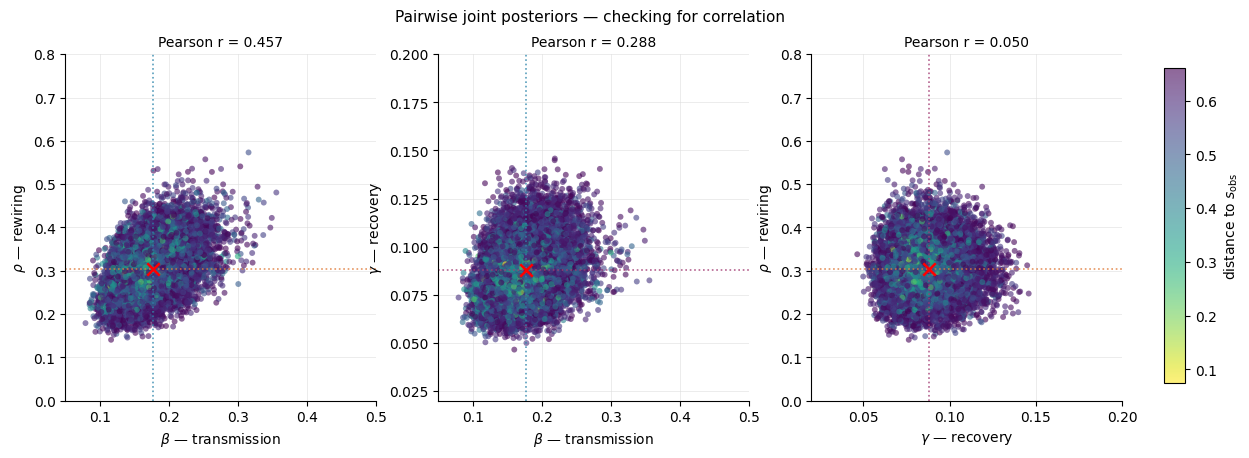

Running PPC with 200 posterior draws...


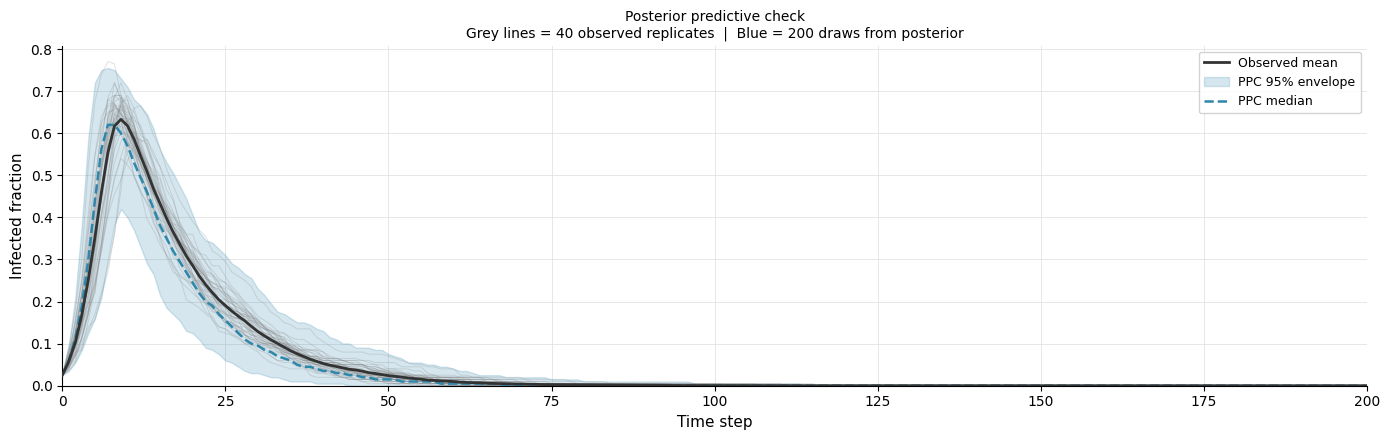

In [ ]:
# ── Posterior Summary Statistics ──────────────────────────────────────────────
print(f"Statistics used:  {STAT_COLS}")
print(f"Accepted:         {len(posterior):,} / {len(sim_df):,}  (ε = {epsilon:.4f})")
print()
print(f"{'param':>6}   {'mean':>8}   {'std':>8}   {'95% CI':>12}   {'contraction':>19}")
print("-" * 70)
for param in ['beta', 'gamma', 'rho']:
    lo_p, hi_p = {'beta':(0.05,0.50), 'gamma':(0.02,0.20), 'rho':(0.0,0.8)}[param]
    v = posterior[param].values
    lo_ci, hi_ci = np.percentile(v, [2.5, 97.5])
    prior_width    = hi_p - lo_p
    post_width     = hi_ci - lo_ci
    contraction    = 1 - post_width / prior_width   # 0 = no learning, 1 = perfect
    print(f"  {param:>5}   {v.mean():>8.4f}   {v.std():>8.4f}   "
          f"[{lo_ci:.4f}, {hi_ci:.4f}]   {contraction:>11.1%}")
    

# ── Plots ────────────────────────────────────────────────────────────────────────
COLORS      = {'beta': '#2E86AB', 'gamma': '#A23B72', 'rho': '#E07B39'}
PRIOR_BOUNDS = {'beta': (0.05, 0.50), 'gamma': (0.02, 0.20), 'rho': (0.00, 0.80)}
PARAM_LABELS = {
    'beta':  r'$\beta$ — transmission',
    'gamma': r'$\gamma$ — recovery',
    'rho':   r'$\rho$ — rewiring',
}

# ── (A) Marginal posteriors ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
fig.suptitle(
    f'Rejection ABC — marginal posteriors\n'
    f'({len(sim_df):,} simulations, top {ACCEPTANCE_RATE*100:.0f}% accepted, '
    f'n = {len(posterior):,},  stats: {STAT_COLS})',
    fontsize=11, y=1.02
)

for ax, param in zip(axes, ['beta', 'gamma', 'rho']):
    color = COLORS[param]
    lo_b, hi_b = PRIOR_BOUNDS[param]
    samples = posterior[param].values
    mean_v  = samples.mean()
    lo_ci, hi_ci = np.percentile(samples, [2.5, 97.5])

    ax.hist(samples, bins=30, density=True,
            color=color, alpha=0.65, edgecolor='white', linewidth=0.5)

    # Prior
    ax.axhline(1.0 / (hi_b - lo_b), color='#555', linewidth=1.4,
               linestyle='--', label='Prior (uniform)')

    # Posterior mean
    ax.axvline(mean_v, color=color, linewidth=2.0, linestyle=':',
               label=f'Mean = {mean_v:.4f}')

    # 95 % CI shading + boundary lines
    ax.axvspan(lo_ci, hi_ci, alpha=0.12, color=color, zorder=0)
    for xv in [lo_ci, hi_ci]:
        ax.axvline(xv, color=color, linewidth=0.9, linestyle='--', alpha=0.7)

    ax.set_xlim(lo_b, hi_b)
    ax.set_xlabel(PARAM_LABELS[param], fontsize=11)
    ax.set_ylabel('Density', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#ddd', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(
        title=f'95% CI  [{lo_ci:.4f}, {hi_ci:.4f}]',
        title_fontsize=8, fontsize=8.5, framealpha=0.85
    )

plt.tight_layout()
plt.show()

# ── (B) Pairwise joint posteriors ────────────────────────────────────────────
# PURPOSE: reveals correlations between parameters in the posterior.
# The β–ρ confound predicts a negative correlation in the β vs ρ panel:
# if your posterior shows a clear diagonal band there, it means the data
# cannot fully separate the two parameters with the current stat set.
# If γ is well-identified, the panels involving γ should look like a
# blob with no clear diagonal structure.

pairs = [('beta', 'rho'), ('beta', 'gamma'), ('gamma', 'rho')]
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.5))
fig2.suptitle('Pairwise joint posteriors — checking for correlation', fontsize=11)

for ax, (px, py) in zip(axes2, pairs):
    x = posterior[px].values
    y = posterior[py].values
    d = posterior['distance'].values  # column of accepted distances
    r = np.corrcoef(x, y)[0, 1]

    sc = ax.scatter(x, y, c=d, cmap='viridis_r', s=18, alpha=0.6,
                    edgecolors='none', zorder=2)

    # posterior mean marker
    ax.scatter(x.mean(), y.mean(), marker='x', color='red',
               s=80, linewidths=1.8, zorder=5)
    ax.axvline(posterior[px].mean(), color=COLORS[px], linewidth=1.2,
               linestyle=':', alpha=0.8)
    ax.axhline(posterior[py].mean(), color=COLORS[py], linewidth=1.2,
               linestyle=':', alpha=0.8)
    
    ax.set_xlim(*PRIOR_BOUNDS[px])
    ax.set_ylim(*PRIOR_BOUNDS[py])
    ax.set_xlabel(PARAM_LABELS[px], fontsize=10)
    ax.set_ylabel(PARAM_LABELS[py], fontsize=10)
    ax.set_title(f'Pearson r = {r:.3f}', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(color='#ddd', linewidth=0.4)
    ax.set_axisbelow(True)

# shared colourbar on the right
fig2.subplots_adjust(right=0.88)
cax = fig2.add_axes([0.91, 0.15, 0.015, 0.7])
cbar = fig2.colorbar(sc, cax=cax)
cbar.set_label(r'distance to $s_\mathrm{obs}$', fontsize=10)

plt.show()

# ── (C) Posterior predictive check (PPC) ─────────────────────────────────────
# For each accepted (β, γ, ρ) sample, run the simulator once and collect
# the infection curve. Then ask: do the simulated curves envelope the
# observed curves? If yes, the posterior is consistent with the data.
# If the observed curves fall mostly outside the simulated envelope,
# the posterior is misspecified — usually caused by poor summary statistics
# or too-large an epsilon.

# We sub-sample 200 posterior draws to keep this fast (~0.3 s).
N_PPC = min(200, len(posterior))
ppc_rng = _rng(3742)
ppc_idx = ppc_rng.choice(len(posterior), size=N_PPC, replace=False)
ppc_rows = posterior.iloc[ppc_idx]
ppc_seeds = ppc_rng.integers(0, 2**31, size=N_PPC)

print(f"Running PPC with {N_PPC} posterior draws...")
ppc_curves = []
for k, (_, row) in enumerate(ppc_rows.iterrows()):
    inf_sim, _, _ = simulate(row['beta'], row['gamma'], row['rho'], seed=int(ppc_seeds[k]))
    ppc_curves.append(inf_sim)
ppc_curves = np.array(ppc_curves)   # (N_PPC, 201)

# Observed curves
obs_curves = np.array([
    inf_df[inf_df['replicate_id'] == rep].sort_values('time')['infected_fraction'].values
    for rep in sorted(inf_df['replicate_id'].unique())
])

time_axis = np.arange(201)
ppc_lo, ppc_med, ppc_hi = np.percentile(ppc_curves, [2.5, 50, 97.5], axis=0)

fig3, ax3 = plt.subplots(figsize=(14, 4.5))

# Observed curves (faint)
for curve in obs_curves:
    ax3.plot(time_axis, curve, color='#888', alpha=0.25, linewidth=0.7)
obs_mean = obs_curves.mean(axis=0)
ax3.plot(time_axis, obs_mean, color='#333', linewidth=2.0,
         label='Observed mean', zorder=5)

# PPC envelope
ax3.fill_between(time_axis, ppc_lo, ppc_hi,
                 color='#2E86AB', alpha=0.20, label='PPC 95% envelope')
ax3.plot(time_axis, ppc_med, color='#2E86AB', linewidth=1.8,
         linestyle='--', label='PPC median')

ax3.set_xlabel('Time step', fontsize=11)
ax3.set_ylabel('Infected fraction', fontsize=11)
ax3.set_title(
    f'Posterior predictive check\n'
    f'Grey lines = {len(obs_curves)} observed replicates  |  '
    f'Blue = {N_PPC} draws from posterior',
    fontsize=10
)
ax3.legend(fontsize=9, framealpha=0.85)
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(color='#ddd', linewidth=0.5)
ax3.set_axisbelow(True)
ax3.set_xlim(0, 200)
ax3.set_ylim(0, None)

plt.tight_layout()
plt.show()

#### Correlation table between posterior esimates and summary statistics

In [9]:
summaries = ['peak', 'peak_t', 'auc', 'peak_rew', 'rew_per_infected', 'var_deg', 'total_rew', 'early', 'duration']
params = ['beta','gamma','rho']
corr_matrix = sim_df[summaries + params].corr()
corr_matrix.loc[summaries, params]

,beta,gamma,rho
peak,0.609614,-0.531830,-0.314908
peak_t,-0.426697,-0.102336,0.014125
auc,0.158341,-0.770066,-0.120015
peak_rew,0.409111,-0.247365,0.683368
rew_per_infected,-0.366914,0.480650,0.620875
var_deg,-0.320179,0.035452,0.652972
total_rew,-0.049743,-0.148137,0.612046
early,-0.003501,-0.310229,-0.174436
duration,0.056165,-0.793303,-0.080866


#### Posterior predictive p-values


Observed test statistics T(y^obs):
                 early: 0.2652
                  late: -0.0276
              duration: 57.5500
             total_rew: 545.1500
            peak_rew_t: 5.5000
          rew_peak_lag: -3.2500
               low_deg: 13.8750

Running PPC with 500 posterior draws (40 reps per draw)...

POSTERIOR PREDICTIVE P-VALUES  (Gelman, Meng & Stern 1996)
           Statistic    T(y_obs)   PPP-value  Assessment
------------------------------------------------------------
               early      0.2652       0.254  ✓  good
                late     -0.0276       0.370  ✓  good
            duration     57.5500       0.384  ✓  good
           total_rew    545.1500       0.370  ✓  good
          peak_rew_t      5.5000       0.356  ✓  good
        rew_peak_lag     -3.2500       0.692  ✓  good
             low_deg     13.8750       0.662  ✓  good
------------------------------------------------------------
PPP near 0.5 = good fit.  < 0.05 or > 0.95 = systematic misfit.


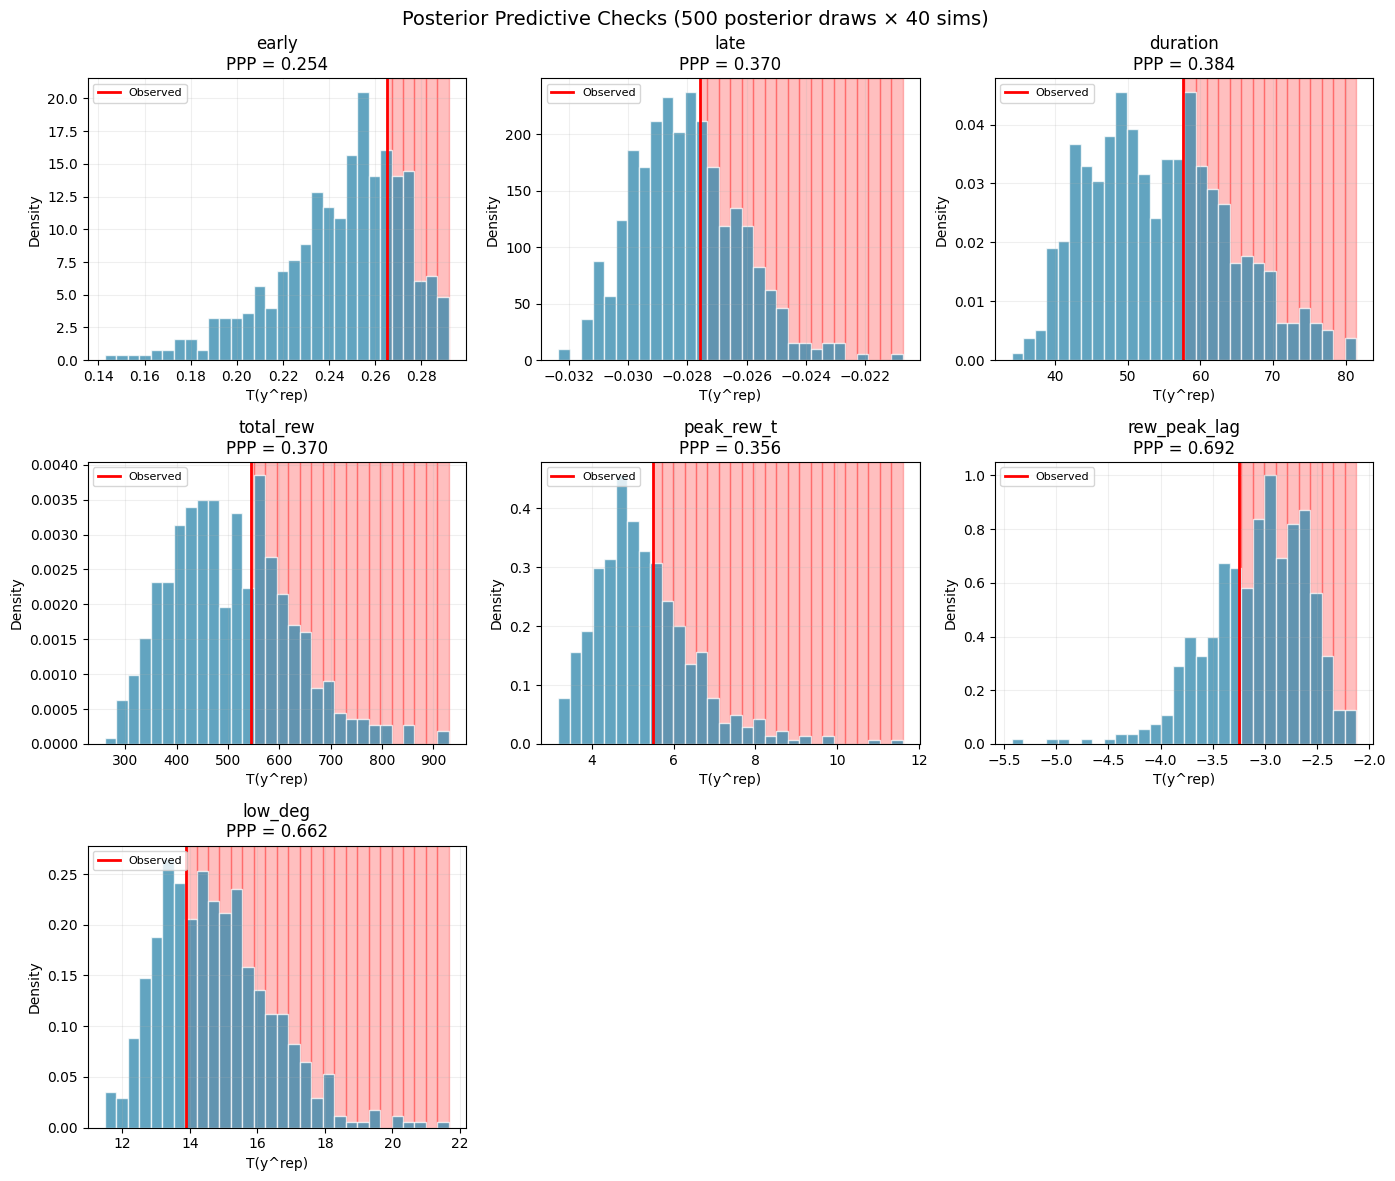

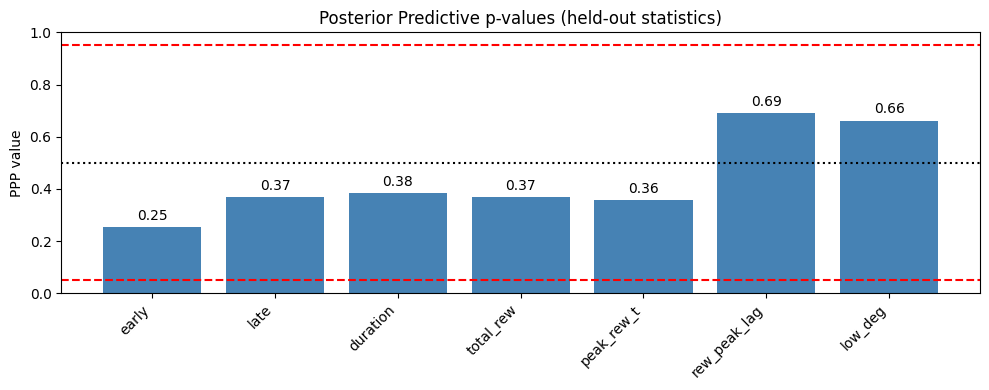

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# POSTERIOR PREDICTIVE P-VALUES (Gelman, Meng & Stern 1996)
#
# Test statistics are held out from STAT_COLS to avoid circular validation.
# compute_all_stats() already computes all of these; we simply select the
# columns that were NOT used in ABC acceptance.
# ─────────────────────────────────────────────────────────────────────────────
# For each accepted posterior sample (β_i, γ_i, ρ_i):
#   1. Re-simulate one trajectory y^rep
#   2. Compute T(y^rep) for each test statistic
#
# PPP-value = fraction of replicates where T(y^rep) >= T(y^obs)
#
# Interpretation:
#   PPP near 0.5  → model reproduces this aspect of the data well
#   PPP < 0.05 or > 0.95  → systematic misfit on this statistic
# ─────────────────────────────────────────────────────────────────────────────

# ── Test statistics (held out from ABC summaries) ────────────────────────────
PPC_COLS = [s for s in obs_mat_df.columns if s not in STAT_COLS and s != 'mean_deg']
# Due to the nature of the rewiring step, the total number of connections remains unchanged.
# Hence, mean_deg is only dependent the initial construction of the network.
# This makes mean_deg uninformative and the decision to exclude it was made. 


# ── Observed test statistic values (mean across 40 replicates) ───────────────
T_obs = obs_mat_df[PPC_COLS].mean()

print("Observed test statistics T(y^obs):")
for k, v in T_obs.items():
    print(f"  {k:>20s}: {v:.4f}")


# ── Draw posterior replicates and compute T(y^rep) ───────────────────────────
N_PPC = min(500, len(posterior))
ppc_sample = posterior.sample(N_PPC, random_state=42)
ppc2_rng = _rng(2347)
ppc2_seeds = ppc2_rng.integers(0, 2**31, size=len(ppc_sample) * 40)
seed_counter = 0

print(f"\nRunning PPC with {N_PPC} posterior draws (40 reps per draw)...")
rep_stats = []

for _, row in ppc_sample.iterrows():
    draw_stats = []
    for _ in range(40):
        inf_r, rew_r, deg_r = simulate(row['beta'], row['gamma'], row['rho'], seed=int(ppc2_seeds[seed_counter]))
        draw_stats.append(compute_all_stats(inf_r, rew_r, np.arange(31), deg_r))
        seed_counter += 1
    draw_df = pd.DataFrame(draw_stats)
    rep_stats.append(draw_df[PPC_COLS].mean().to_dict())

rep_df = pd.DataFrame(rep_stats)


# ── Compute and report PPP-values ─────────────────────────────────────────────
# PPP = fraction of replicates where T(y^rep) >= T(y^obs)
ppp_values = {
    stat: float(np.mean(rep_df[stat].values >= T_obs[stat]))
    for stat in PPC_COLS
}

print("\n" + "="*60)
print("POSTERIOR PREDICTIVE P-VALUES  (Gelman, Meng & Stern 1996)")
print("="*60)
print(f"{'Statistic':>20}  {'T(y_obs)':>10}  {'PPP-value':>10}  Assessment")
print("-"*60)
for stat in PPC_COLS:
    ppp = ppp_values[stat]
    flag = "⚠  MISFIT" if (ppp < 0.05 or ppp > 0.95) else \
           "~  marginal" if (ppp < 0.10 or ppp > 0.90) else "✓  good"
    print(f"  {stat:>18s}  {T_obs[stat]:>10.4f}  {ppp:>10.3f}  {flag}")
print("-"*60)
print("PPP near 0.5 = good fit.  < 0.05 or > 0.95 = systematic misfit.")


# ── Plot ──────────────────────────────────────────────────────────────────────
n_stats = len(PPC_COLS)
cols = 3
rows = int(np.ceil(n_stats / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, stat in enumerate(PPC_COLS):
    rep_vals = rep_df[stat].values
    obs_val = T_obs[stat]
    ppp = ppp_values[stat]

    axes[i].hist(rep_vals, bins=30, density=True,
                 alpha=0.75, color='#2E86AB', edgecolor='white')
    axes[i].axvline(obs_val, color='red', linewidth=2, label='Observed')

    bins = np.histogram_bin_edges(rep_vals, bins=30)
    for j in range(len(bins) - 1):
        left, right = bins[j], bins[j + 1]
        if right > obs_val:
            axes[i].axvspan(max(left, obs_val), right,
                            color='red', alpha=0.25, zorder=0)

    axes[i].set_title(f"{stat}\nPPP = {ppp:.3f}")
    axes[i].set_xlabel("T(y^rep)")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Posterior Predictive Checks ({N_PPC} posterior draws × 40 sims)", fontsize=14)
plt.tight_layout()
plt.show()

# ── PPP Summary barplot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ppps = [ppp_values[s] for s in PPC_COLS]
colors = ['red' if (p < 0.05 or p > 0.95) else
          'orange' if (p < 0.1 or p > 0.9) else 'steelblue'
          for p in ppps]

bars = ax.bar(PPC_COLS, ppps, color=colors)
ax.axhline(0.5, linestyle=':', color='black')
ax.axhline(0.05, linestyle='--', color='red')
ax.axhline(0.95, linestyle='--', color='red')
ax.set_ylim(0, 1)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel("PPP value")
ax.set_title("Posterior Predictive p-values (held-out statistics)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Bayesian Synthetic Likelihood (Claude)

#### Define necessary functions for BSL

Note that `peak_t` is not used in BSL as it violates the normality assumption of summary statistics in synthetic likelihood (values are discrete non negative integers). A transformation could be applied, however as there were only 8 unique values, the decision to drop `peak_t` was made.

In [ ]:
# =============================================================================
# Bayesian Synthetic Likelihood (BSL) for the Adaptive-Network SIR Model
# =============================================================================
"""
Implements the BSL method of Wood (2010) and Price et al. (2018),
run via Metropolis-Hastings MCMC as described in Frazier et al. (2019).
 
HOW BSL WORKS
-------------
Standard Bayesian inference requires evaluating the likelihood p(y | theta),
which is intractable for this stochastic network model. BSL replaces it with
a tractable Gaussian approximation.
 
The key observation (Wood 2010) is that well-chosen summary statistics S(z)
satisfy a central limit theorem: for large N, S(z) | theta is approximately
Normal with mean b(theta) = E[S(z) | theta] and covariance Sigma(theta).
 
Rather than evaluating p(y | theta) directly, BSL evaluates:
    p_SL(S_obs | theta) = N(S_obs ; b(theta), Sigma(theta))
 
Since b(theta) and Sigma(theta) are unknown, they are estimated using M
independent simulations z^1, ..., z^M from the model at theta:
    b_hat(theta)     = (1/M) * sum_i S(z^i)
    Sigma_hat(theta) = sample covariance of {S(z^1), ..., S(z^M)}
 
The resulting noisy synthetic likelihood N(S_obs ; b_hat, Sigma_hat) is used
inside Metropolis-Hastings MCMC to draw samples from the BSL posterior:
    pi_B(theta | S_obs)  ∝  pi(theta) * N(S_obs ; b_hat(theta), Sigma_hat(theta))
 
This is a pseudo-marginal MCMC scheme (Andrieu & Roberts 2009): we never
evaluate the true likelihood, only an unbiased Monte Carlo estimate of it.
Price et al. (2018) prove this scheme targets a well-defined BSL posterior
that concentrates around the true partial posterior as M -> infinity.
 
KEY DIFFERENCES FROM ABC
------------------------
- ABC estimates the likelihood non-parametrically using a kernel K_eps(||S_obs - S(z)||).
  This suffers from the curse of dimensionality as d_s grows.
- BSL parametrically approximates p(S | theta) as Gaussian, which scales as O(d_s^2)
  (the covariance matrix), avoiding the curse of dimensionality.
- ABC requires tuning epsilon; BSL requires tuning M.
- BSL requires the normality assumption for S(z) | theta; ABC does not.
 
 
REFERENCES
----------
Wood (2010), Statistical Science.
Price et al. (2018), Statistics and Computing.
Frazier et al. (2019), Journal of Computational and Graphical Statistics.
Beaumont et al. (2002), Genetics. [regression adjustment used in ABC section]
"""


# =============================================================================
# STATISTIC SETS
# =============================================================================
 
# ABC uses all 6 (including peak_t — kernel distance needs no normality)
ABC_STAT_COLS = ['peak', 'peak_t', 'auc', 'rew_per_infected', 'peak_rew', 'var_deg']
 
# BSL uses 5 — peak_t excluded due to violaton of normality
BSL_STAT_COLS = ['peak', 'auc', 'rew_per_infected', 'peak_rew', 'var_deg']
 
S_obs_bsl = S_obs_full[BSL_STAT_COLS].values.copy()
d_s = len(BSL_STAT_COLS)
 
print(f"\nBSL statistic set ({d_s} statistics): {BSL_STAT_COLS}")
 
# =============================================================================
# BSL CORE: SYNTHETIC LOG-LIKELIHOOD
# =============================================================================
bsl_rng = _rng(4237)

def synthetic_log_likelihood(theta, S_obs, M=50, ridge=1e-6):
    """
    Estimate the log synthetic likelihood at theta using M simulations.
 
    Mechanism (Wood 2010, Price et al. 2018):
    -----------------------------------------
    1. Simulate M independent datasets z^1, ..., z^M from the model at theta.
    2. Compute summary statistics s^i = S(z^i) for each simulation.
    3. Estimate:
         b_hat     = (1/M) * sum_i s^i          [mean of summaries at theta]
         Sigma_hat = sample covariance of s^1,...,s^M  [variance of summaries at theta]
    4. Return log N(S_obs ; b_hat, Sigma_hat)
       = -0.5 * (d_s * log(2*pi) + log|Sigma_hat| + (S_obs - b_hat)^T Sigma_hat^{-1} (S_obs - b_hat))
 
    The ridge term stabilises Sigma_hat when M is small relative to d_s.
 
    Parameters
    ----------
    theta : array-like, shape (3,)  — [beta, gamma, rho]
    S_obs : array, shape (d_s,)     — observed summary statistics
    M     : int                     — number of simulations (>= d_s^2 recommended)
    ridge : float                   — regularisation added to diagonal of Sigma_hat
 
    Returns
    -------
    float : log synthetic likelihood (or -inf if model fails)
    """
    beta, gamma, rho = theta
 
    # Simulate M independent summaries at theta
    sim_stats = np.empty((M, len(S_obs)))
    bsl_sim_seeds = bsl_rng.integers(0, 2**31, size=M)
    for i in range(M):
        inf_s, rew_s, deg_s = simulate(beta, gamma, rho, seed=int(bsl_sim_seeds[i]))
        s = compute_all_stats(inf_s, rew_s, np.arange(31), deg_s)
        sim_stats[i] = [s[k] for k in BSL_STAT_COLS]
 
    # Estimate mean and covariance (Price et al. 2018, equations 2-3)
    b_hat     = sim_stats.mean(axis=0)
    Sigma_hat = np.cov(sim_stats, rowvar=False)
 
    # Regularise: add ridge to diagonal for numerical stability
    # This is equivalent to Warton (2008) shrinkage with gamma -> 0
    Sigma_hat += ridge * np.eye(len(S_obs))
 
    # Evaluate multivariate normal log-density at S_obs
    try:
        log_sl = stats.multivariate_normal.logpdf(S_obs, mean=b_hat, cov=Sigma_hat)
    except np.linalg.LinAlgError:
        return -np.inf
 
    if not np.isfinite(log_sl):
        return -np.inf
 
    return float(log_sl)
 
 
# =============================================================================
# BSL CORE: LOG PRIOR
# =============================================================================
 
PRIOR_BOUNDS = {
    'beta':  (0.05, 0.50),
    'gamma': (0.02, 0.20),
    'rho':   (0.00, 0.80),
}
 
def log_prior(theta):
    """
    Uniform prior over (beta, gamma, rho).
    Returns log(1 / (prior volume)) = constant if in bounds, -inf otherwise.
    """
    beta, gamma, rho = theta
    if (PRIOR_BOUNDS['beta'][0]  <= beta  <= PRIOR_BOUNDS['beta'][1]  and
        PRIOR_BOUNDS['gamma'][0] <= gamma <= PRIOR_BOUNDS['gamma'][1] and
        PRIOR_BOUNDS['rho'][0]   <= rho   <= PRIOR_BOUNDS['rho'][1]):
        return 0.0    # log(constant) — normalising constant cancels in MH ratio
    return -np.inf
 
 
# =============================================================================
# BSL MCMC: METROPOLIS-HASTINGS
# =============================================================================
mcmc_rng = _rng(7432)

def run_bsl_mcmc(S_obs, n_iter=15_000, M=50, proposal_cov=None, theta_init=None):
    """
    Metropolis-Hastings MCMC for Bayesian Synthetic Likelihood.
 
    Algorithm (Price et al. 2018, Algorithm 1):
    --------------------------------------------
    At each step t:
      1. Propose theta* ~ N(theta_{t-1}, Sigma_prop)
      2. If theta* outside prior support: reject, set theta_t = theta_{t-1}
      3. Compute log_SL(theta*) by running M simulations (synthetic_log_likelihood)
      4. MH log-acceptance ratio:
           log alpha = [log pi(theta*) + log_SL(theta*)]
                     - [log pi(theta_{t-1}) + log_SL(theta_{t-1})]
      5. Accept theta* with probability min(1, exp(log alpha))
 
    The log_SL at the current theta is cached between iterations (only the
    proposed theta needs M fresh simulations per step). This is the standard
    pseudo-marginal approach (Andrieu & Roberts 2009).
 
    Parameters
    ----------
    S_obs         : observed summaries, shape (d_s,)
    n_iter        : total MCMC iterations (including burn-in)
    M             : simulations per likelihood evaluation
    proposal_cov  : proposal covariance; defaults to tuned diagonal
    theta_init    : starting point; defaults to ABC posterior mean
 
    Returns
    -------
    chain : np.ndarray, shape (n_iter, 3) — full MCMC chain (including burn-in)
    accept_rate : float — MH acceptance rate
    """
    # ── Initialisation ────────────────────────────────────────────────────────
    if theta_init is None:
        # Start at ABC posterior mean (warm start avoids long burn-in)
        theta_init = np.array([0.177, 0.088, 0.305])
 
    if proposal_cov is None:
        # Tuned diagonal proposal: roughly 1/5 of prior width per parameter.
        # Target acceptance rate ~23% (Roberts & Rosenthal 2001 optimal for d=3).
        proposal_cov = np.diag([0.015**2, 0.008**2, 0.025**2])
 
    theta_curr = np.array(theta_init, dtype=float)
    chain      = np.empty((n_iter, 3))
    n_accept   = 0
 
    # Compute log-posterior at starting point
    log_prior_curr = log_prior(theta_curr)
    log_sl_curr    = synthetic_log_likelihood(theta_curr, S_obs, M=M)
    log_post_curr  = log_prior_curr + log_sl_curr
 
    print(f"Initial log-posterior: {log_post_curr:.3f}")
    print(f"Running {n_iter:,} MCMC iterations (M={M} sims/step)...")
    print(f"Estimated total simulations: {n_iter * M:,}\n")
 
    for t in range(n_iter):
        # Step 1: propose
        theta_prop = mcmc_rng.multivariate_normal(theta_curr, proposal_cov)
 
        # Step 2-4: compute acceptance ratio
        log_prior_prop = log_prior(theta_prop)
        if log_prior_prop == -np.inf:
            # Outside prior — reject immediately (no simulations wasted)
            chain[t] = theta_curr
            continue
 
        log_sl_prop    = synthetic_log_likelihood(theta_prop, S_obs, M=M)
        log_post_prop  = log_prior_prop + log_sl_prop
 
        log_alpha = log_post_prop - log_post_curr
 
        # Step 5: accept/reject
        if np.log(mcmc_rng.uniform()) < log_alpha:
            theta_curr     = theta_prop
            log_post_curr  = log_post_prop
            n_accept      += 1
 
        chain[t] = theta_curr
 
        if (t + 1) % max(1, n_iter // 10) == 0:
            current_rate = n_accept / (t + 1) * 100
            print(f"  Iteration {t+1:>6,} / {n_iter:,}   acceptance rate: {current_rate:.1f}%")
 
    accept_rate = n_accept / n_iter
    return chain, accept_rate


BSL statistic set (5 statistics): ['peak', 'auc', 'rew_per_infected', 'peak_rew', 'var_deg']


#### Run BSL

This code is computationally expensive, on average it takes 15min for 1 million simulations


In [ ]:
# =============================================================================
# RUN BSL
# =============================================================================
# Feel free to edit these values to your preference, generally keep M > 20
N_ITER   = 20_000  # total MCMC iterations
BURN_IN  = 5000    # discard first 5000 (warm-up)
M_BSL    = 50      # simulations per likelihood evaluation
# Total: 20,000 * 50 = 1,000,000 simulations 
# Same number of simulations as ABC

print("\n" + "=" * 65)
print("RUNNING BSL MCMC")
print("=" * 65)
print(f"  Statistics   : {BSL_STAT_COLS}")
print(f"  M per step   : {M_BSL}")
print(f"  Total iters  : {N_ITER:,}  (burn-in: {BURN_IN:,})")
print(f"  Total sims   : {N_ITER * M_BSL:,}")
print()

chain, accept_rate = run_bsl_mcmc(
    S_obs     = S_obs_bsl,
    n_iter    = N_ITER,
    M         = M_BSL,
    # Initial parameter value = Expected value of prior
    theta_init= np.array([0.275, 0.11, 0.40]),
)

# Discard burn-in
posterior_bsl = chain[BURN_IN:]
df_bsl = pd.DataFrame(posterior_bsl, columns=['beta', 'gamma', 'rho'])
 
print(f"\nMH acceptance rate: {accept_rate:.1%}")


RUNNING BSL MCMC
  Statistics   : ['peak', 'auc', 'rew_per_infected', 'peak_rew', 'var_deg']
  M per step   : 50
  Total iters  : 20,000  (burn-in: 5,000)
  Total sims   : 1,000,000

Initial log-posterior: -37.758
Running 20,000 MCMC iterations (M=50 sims/step)...
Estimated total simulations: 1,000,000

  Iteration  2,000 / 20,000   acceptance rate: 28.6%
  Iteration  4,000 / 20,000   acceptance rate: 29.2%
  Iteration  6,000 / 20,000   acceptance rate: 29.3%
  Iteration  8,000 / 20,000   acceptance rate: 29.5%
  Iteration 10,000 / 20,000   acceptance rate: 29.7%
  Iteration 12,000 / 20,000   acceptance rate: 29.9%
  Iteration 14,000 / 20,000   acceptance rate: 30.3%
  Iteration 16,000 / 20,000   acceptance rate: 30.1%
  Iteration 18,000 / 20,000   acceptance rate: 30.4%
  Iteration 20,000 / 20,000   acceptance rate: 30.3%

MH acceptance rate: 30.3%


#### BSL posterior summary and plots


BSL POSTERIOR SUMMARY

 param       mean        std         95% CI           contraction
----------------------------------------------------------------------
   beta     0.1572     0.0254   [0.1150, 0.2207]         76.5%
  gamma     0.0812     0.0056   [0.0708, 0.0923]         88.1%
    rho     0.3070     0.0328   [0.2506, 0.3816]         83.6%

Posterior correlations:
  beta-rho: 0.828
  beta-gamma: -0.001
  gamma-rho: 0.011


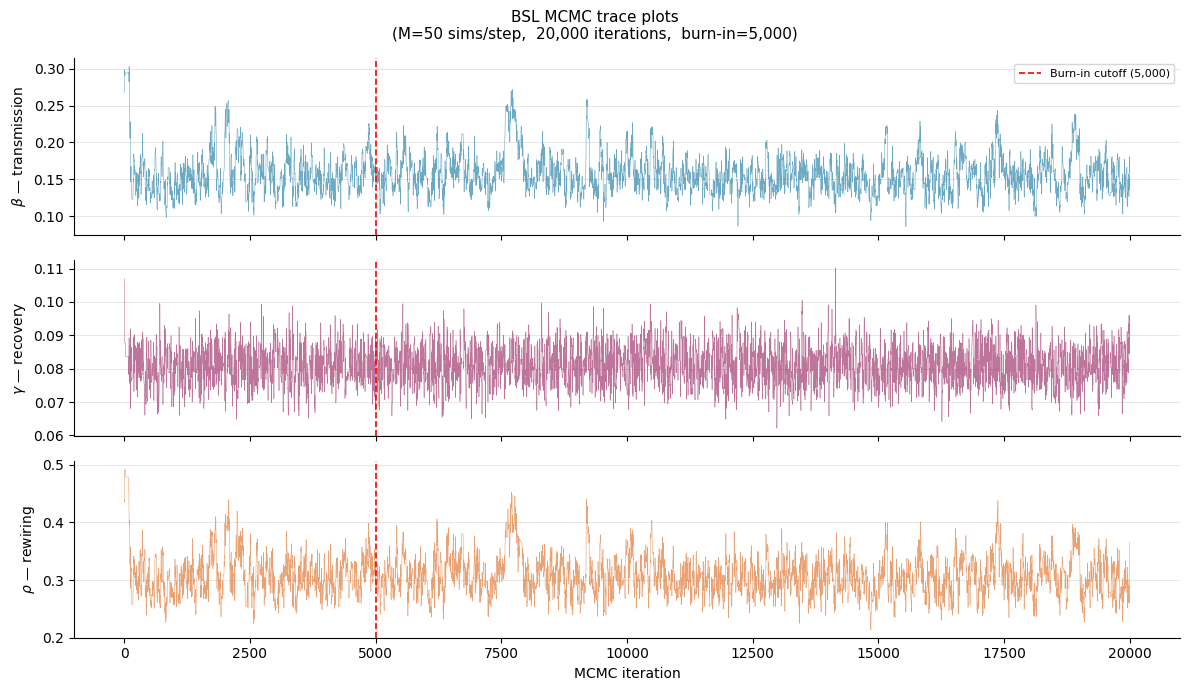

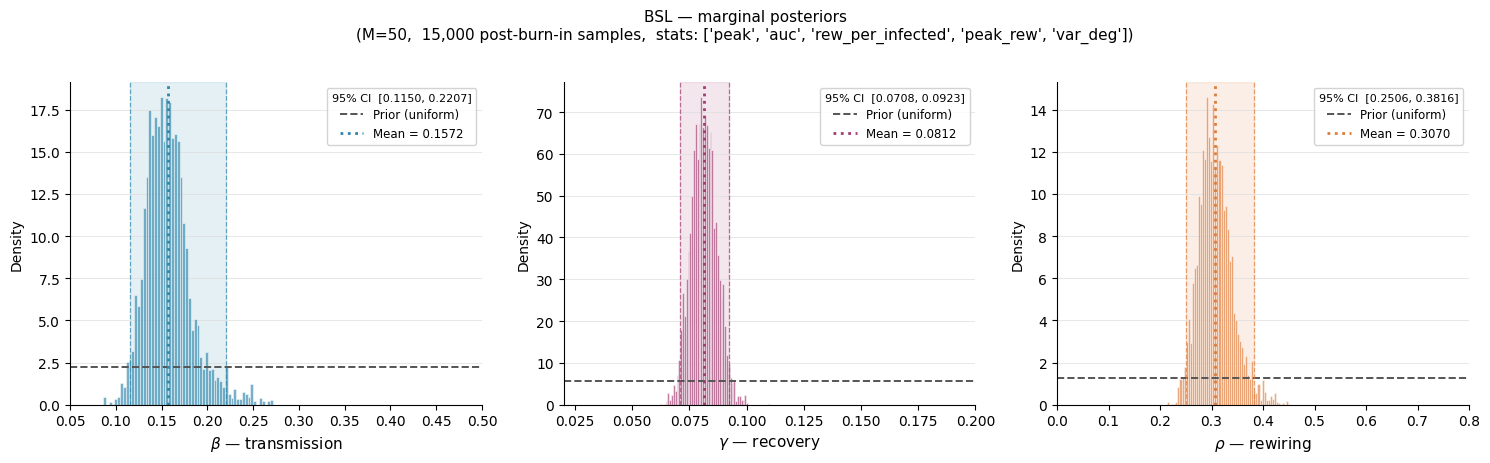

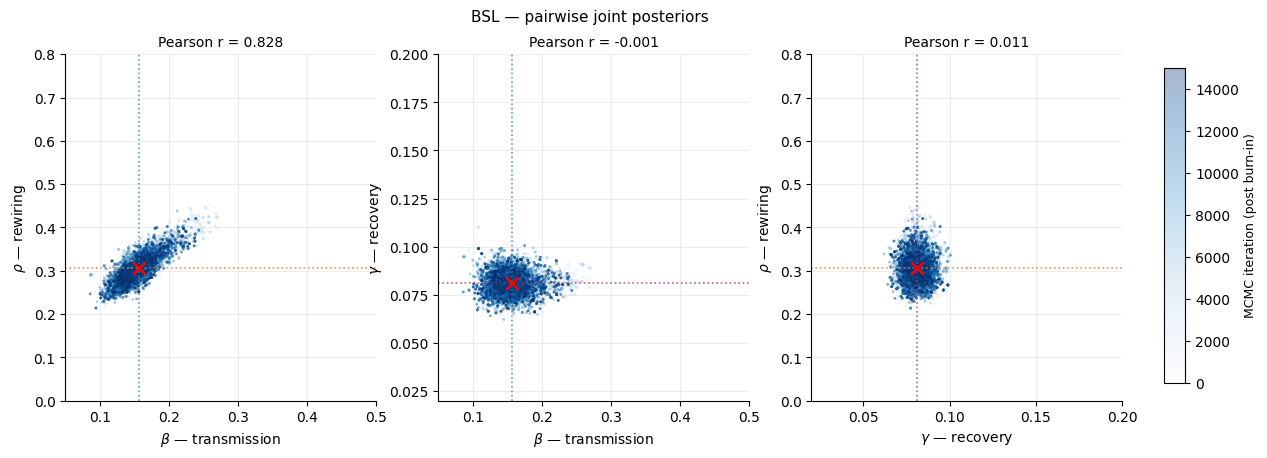


Running PPC with 200 posterior draws...


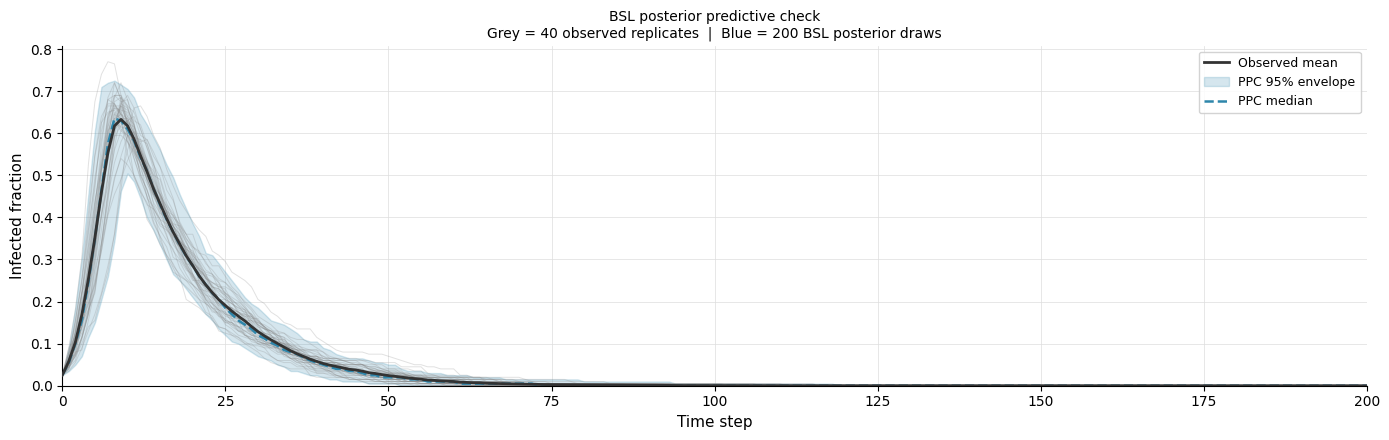

In [15]:
# =============================================================================
# BSL POSTERIOR SUMMARY
# =============================================================================
 
COLORS      = {'beta': '#2E86AB', 'gamma': '#A23B72', 'rho': '#E07B39'}
PARAM_LABELS = {
    'beta':  r'$\beta$ — transmission',
    'gamma': r'$\gamma$ — recovery',
    'rho':   r'$\rho$ — rewiring',
}
 
print("\n" + "=" * 70)
print("BSL POSTERIOR SUMMARY")
print("=" * 70)
print(f"\n{'param':>6}   {'mean':>8}   {'std':>8}   {'95% CI':>12}   {'contraction':>19}")
print("-" * 70)
for param in ['beta', 'gamma', 'rho']:
    lo_p, hi_p = PRIOR_BOUNDS[param]
    v = df_bsl[param].values
    lo_ci, hi_ci = np.percentile(v, [2.5, 97.5])
    contraction = 1 - (hi_ci - lo_ci) / (hi_p - lo_p)
    print(f"  {param:>5}   {v.mean():>8.4f}   {v.std():>8.4f}   "
          f"[{lo_ci:.4f}, {hi_ci:.4f}]   {contraction:>11.1%}")
 
print(f"\nPosterior correlations:")
for px, py in [('beta', 'rho'), ('beta', 'gamma'), ('gamma', 'rho')]:
    r = np.corrcoef(df_bsl[px], df_bsl[py])[0, 1]
    print(f"  {px}-{py}: {r:.3f}")
 
# =============================================================================
# PLOT A — TRACE PLOTS (MCMC-specific diagnostic, not in ABC)
# =============================================================================
# Trace plots show the MCMC chain over iterations.
# A well-mixing chain looks like white noise around a stable mean.
# Trends, slow drifts, or stuck regions indicate convergence problems.
 
fig_trace, axes_trace = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
fig_trace.suptitle(
    f'BSL MCMC trace plots\n'
    f'(M={M_BSL} sims/step,  {N_ITER:,} iterations,  burn-in={BURN_IN:,})',
    fontsize=11
)
 
for ax, param in zip(axes_trace, ['beta', 'gamma', 'rho']):
    color = COLORS[param]
    full_chain = chain[:, ['beta', 'gamma', 'rho'].index(param)]
    ax.plot(full_chain, color=color, linewidth=0.4, alpha=0.7)
    ax.axvline(BURN_IN, color='red', linewidth=1.2, linestyle='--',
               label=f'Burn-in cutoff ({BURN_IN:,})')
    ax.set_ylabel(PARAM_LABELS[param], fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#ddd', linewidth=0.5)
    ax.set_axisbelow(True)
    if ax == axes_trace[0]:
        ax.legend(fontsize=8)
 
axes_trace[-1].set_xlabel('MCMC iteration', fontsize=10)
plt.tight_layout()
plt.show()
 
# =============================================================================
# PLOT B — MARGINAL POSTERIORS (same style as ABC)
# =============================================================================
 
fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4.5))
fig1.suptitle(
    f'BSL — marginal posteriors\n'
    f'(M={M_BSL},  {N_ITER - BURN_IN:,} post-burn-in samples,  '
    f'stats: {BSL_STAT_COLS})',
    fontsize=11, y=1.02
)
 
for ax, param in zip(axes1, ['beta', 'gamma', 'rho']):
    color = COLORS[param]
    lo_b, hi_b = PRIOR_BOUNDS[param]
    samples = df_bsl[param].values
    mean_v  = samples.mean()
    lo_ci, hi_ci = np.percentile(samples, [2.5, 97.5])
 
    ax.hist(samples, bins=60, density=True,
            color=color, alpha=0.65, edgecolor='white', linewidth=0.5)
    ax.axhline(1.0 / (hi_b - lo_b), color='#555', linewidth=1.4,
               linestyle='--', label='Prior (uniform)')
    ax.axvline(mean_v, color=color, linewidth=2.0, linestyle=':',
               label=f'Mean = {mean_v:.4f}')
    ax.axvspan(lo_ci, hi_ci, alpha=0.12, color=color, zorder=0)
    for xv in [lo_ci, hi_ci]:
        ax.axvline(xv, color=color, linewidth=0.9, linestyle='--', alpha=0.7)
 
    ax.set_xlim(lo_b, hi_b)
    ax.set_xlabel(PARAM_LABELS[param], fontsize=11)
    ax.set_ylabel('Density', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', color='#ddd', linewidth=0.5, zorder=0)
    ax.set_axisbelow(True)
    ax.legend(
        title=f'95% CI  [{lo_ci:.4f}, {hi_ci:.4f}]',
        title_fontsize=8, fontsize=8.5, framealpha=0.85
    )
 
plt.tight_layout()
plt.show()
 
# =============================================================================
# PLOT C — JOINT POSTERIORS (same style as ABC)
# =============================================================================
 
pairs = [('beta', 'rho'), ('beta', 'gamma'), ('gamma', 'rho')]
fig2, axes2 = plt.subplots(1, 3, figsize=(14, 4.5))
fig2.suptitle('BSL — pairwise joint posteriors', fontsize=11)
 
for ax, (px, py) in zip(axes2, pairs):
    x = df_bsl[px].values
    y = df_bsl[py].values
    r = np.corrcoef(x, y)[0, 1]
 
    # Colour points by iteration number to reveal any remaining drift
    iter_idx = np.arange(len(x))
    sc = ax.scatter(x, y, c=iter_idx, cmap='Blues', s=4, alpha=0.35,
                    edgecolors='none', zorder=2)
 
    ax.scatter(x.mean(), y.mean(), marker='x', color='red',
               s=80, linewidths=1.8, zorder=5, label='Posterior mean')
    ax.axvline(x.mean(), color=COLORS[px], linewidth=1.2, linestyle=':', alpha=0.8)
    ax.axhline(y.mean(), color=COLORS[py], linewidth=1.2, linestyle=':', alpha=0.8)
 
    ax.set_xlim(*PRIOR_BOUNDS[px])
    ax.set_ylim(*PRIOR_BOUNDS[py])
    ax.set_xlabel(PARAM_LABELS[px], fontsize=10)
    ax.set_ylabel(PARAM_LABELS[py], fontsize=10)
    ax.set_title(f'Pearson r = {r:.3f}', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(color='#ddd', linewidth=0.4)
    ax.set_axisbelow(True)
    
 
fig2.subplots_adjust(right=0.88)
cax = fig2.add_axes([0.91, 0.15, 0.015, 0.7])
cbar = fig2.colorbar(sc, cax=cax)
cbar.set_label('MCMC iteration (post burn-in)', fontsize=9)
 
plt.show()
 
# =============================================================================
# PLOT D — POSTERIOR PREDICTIVE CHECK (same as ABC)
# =============================================================================
N_PPC = 200
bsl_ppc_rng = _rng(2734)
ppc_idx = bsl_ppc_rng.choice(len(df_bsl), size=N_PPC, replace=False)
ppc_rows = df_bsl.iloc[ppc_idx]
bsl_ppc_seeds = bsl_ppc_rng.integers(0, 2**31, size=N_PPC)

print(f"\nRunning PPC with {N_PPC} posterior draws...")
ppc_curves = []
for k, (_, row) in enumerate(ppc_rows.iterrows()):
    inf_sim, _, _ = simulate(row['beta'], row['gamma'], row['rho'], seed=int(bsl_ppc_seeds[k]))
    ppc_curves.append(inf_sim)
ppc_curves = np.array(ppc_curves)
 
obs_curves = np.array([
    inf_df[inf_df['replicate_id'] == rep].sort_values('time')['infected_fraction'].values
    for rep in sorted(inf_df['replicate_id'].unique())
])
 
time_axis = np.arange(201)
ppc_lo, ppc_med, ppc_hi = np.percentile(ppc_curves, [2.5, 50, 97.5], axis=0)
 
fig3, ax3 = plt.subplots(figsize=(14, 4.5))
for curve in obs_curves:
    ax3.plot(time_axis, curve, color='#888', alpha=0.25, linewidth=0.7)
obs_mean = obs_curves.mean(axis=0)
ax3.plot(time_axis, obs_mean, color='#333', linewidth=2.0,
         label='Observed mean', zorder=5)
ax3.fill_between(time_axis, ppc_lo, ppc_hi,
                 color='#2E86AB', alpha=0.20, label='PPC 95% envelope')
ax3.plot(time_axis, ppc_med, color='#2E86AB', linewidth=1.8,
         linestyle='--', label='PPC median')
ax3.set_xlabel('Time step', fontsize=11)
ax3.set_ylabel('Infected fraction', fontsize=11)
ax3.set_title(
    f'BSL posterior predictive check\n'
    f'Grey = {len(obs_curves)} observed replicates  |  '
    f'Blue = {N_PPC} BSL posterior draws',
    fontsize=10
)
ax3.legend(fontsize=9, framealpha=0.85)
ax3.spines[['top', 'right']].set_visible(False)
ax3.grid(color='#ddd', linewidth=0.5)
ax3.set_axisbelow(True)
ax3.set_xlim(0, 200)
ax3.set_ylim(0, None)
plt.tight_layout()
plt.show()

Observed test statistics T(y^obs):
                peak_t: 8.7500
                 early: 0.2652
                  late: -0.0276
              duration: 57.5500
             total_rew: 545.1500
            peak_rew_t: 5.5000
          rew_peak_lag: -3.2500
               low_deg: 13.8750

Running PPC with 500 posterior draws (40 reps per draw)...

POSTERIOR PREDICTIVE P-VALUES  (Gelman, Meng & Stern 1996)
           Statistic    T(y_obs)   PPP-value  Assessment
------------------------------------------------------------
              peak_t      8.7500       0.526  ✓  good
               early      0.2652       0.534  ✓  good
                late     -0.0276       0.436  ✓  good
            duration     57.5500       0.472  ✓  good
           total_rew    545.1500       0.498  ✓  good
          peak_rew_t      5.5000       0.556  ✓  good
        rew_peak_lag     -3.2500       0.536  ✓  good
             low_deg     13.8750       0.932  ~  marginal
-------------------------------------

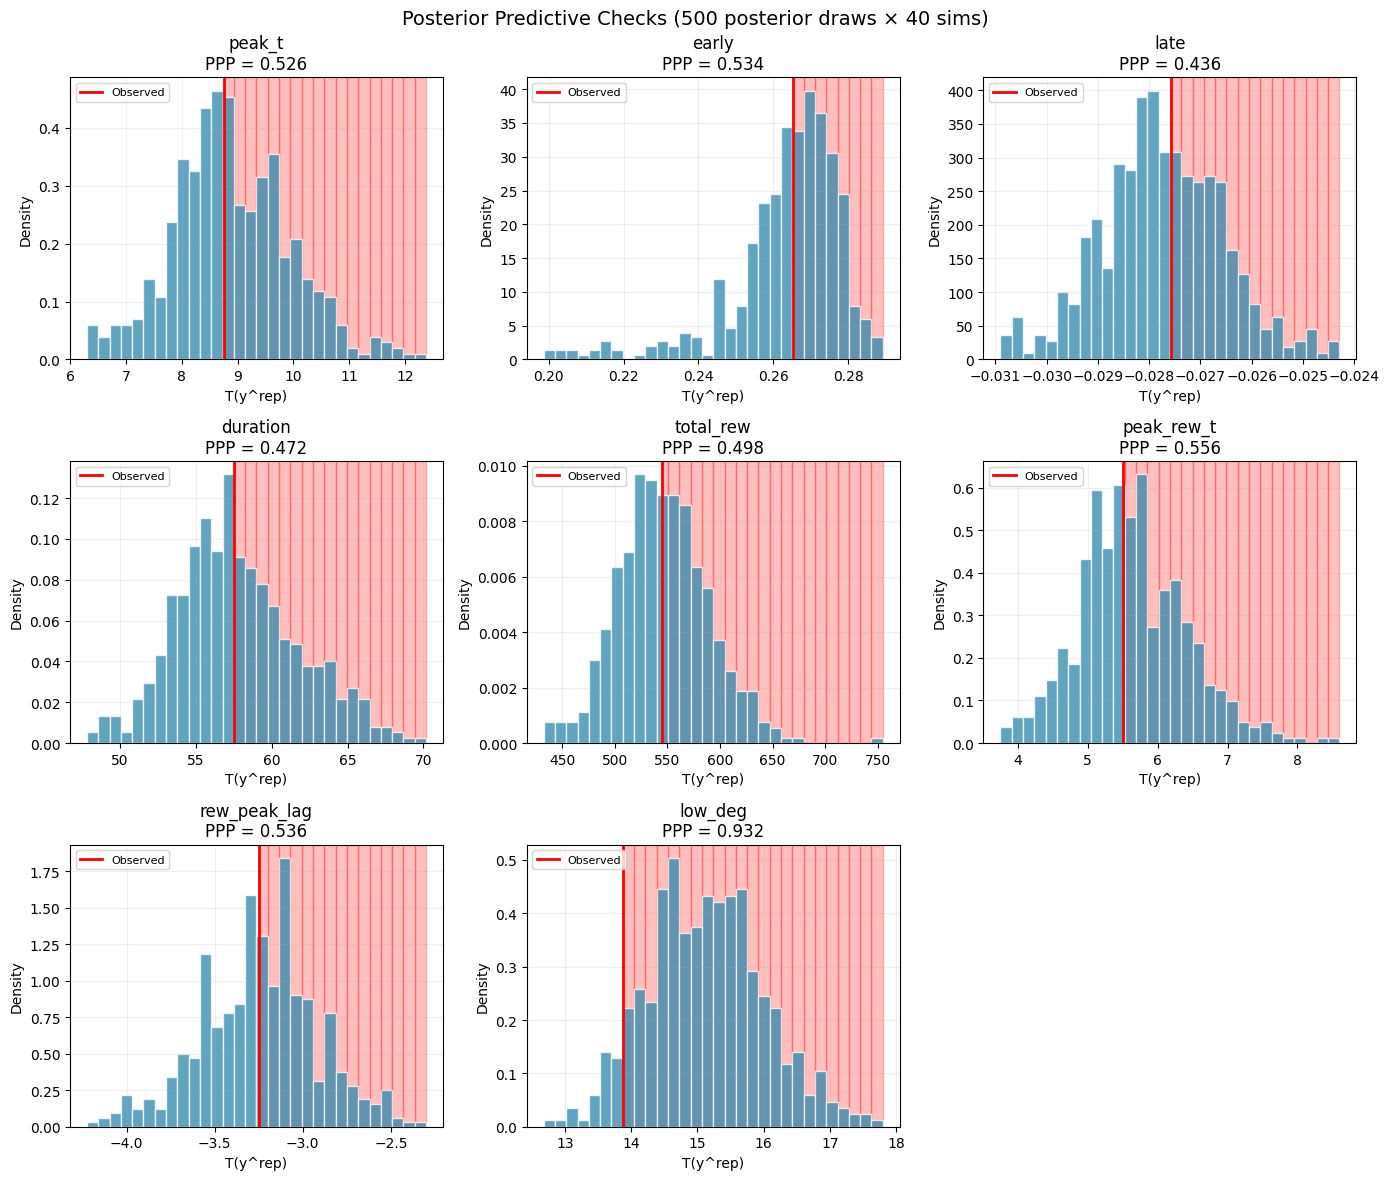

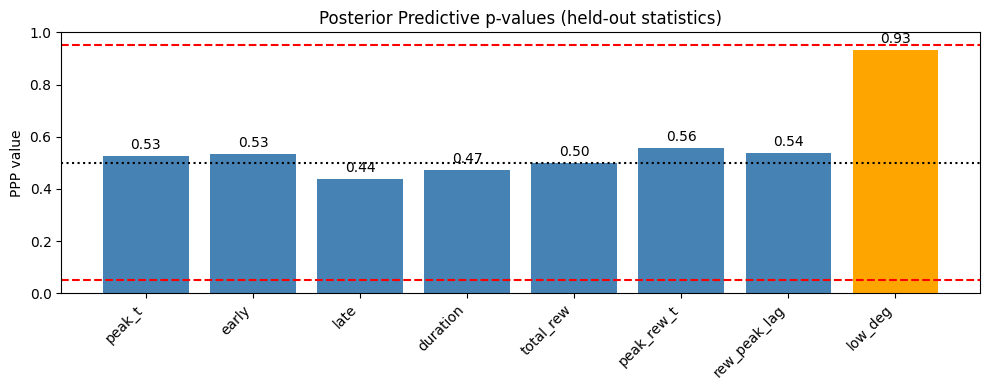

In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# POSTERIOR PREDICTIVE CHECK (Gelman, Meng & Stern 1996)
# ─────────────────────────────────────────────────────────────────────────────


# ── Test statistics (held out from ABC summaries) ────────────────────────────
PPC_COLS = [s for s in obs_mat_df.columns if s not in BSL_STAT_COLS and s != 'mean_deg']

# ── Observed test statistic values (mean across 40 replicates) ───────────────
T_obs = obs_mat_df[PPC_COLS].mean()

print("Observed test statistics T(y^obs):")
for k, v in T_obs.items():
    print(f"  {k:>20s}: {v:.4f}")

# ── Draw posterior replicates and compute T(y^rep) ───────────────────────────
N_PPC = min(500, len(posterior))
ppc_sample = df_bsl.sample(N_PPC, random_state=42)
ppc3_rng = _rng(4732)
ppc3_seeds = ppc3_rng.integers(0, 2**31, size=len(ppc_sample) * 40)
seed_counter = 0

print(f"\nRunning PPC with {N_PPC} posterior draws (40 reps per draw)...")
rep_stats = []

for _, row in ppc_sample.iterrows():
    draw_stats = []
    for _ in range(40):
        inf_r, rew_r, deg_r = simulate(row['beta'], row['gamma'], row['rho'], seed=int(ppc3_seeds[seed_counter]))
        draw_stats.append(compute_all_stats(inf_r, rew_r, np.arange(31), deg_r))
        seed_counter += 1
    draw_df = pd.DataFrame(draw_stats)
    rep_stats.append(draw_df[PPC_COLS].mean().to_dict())

rep_df = pd.DataFrame(rep_stats)


# ── Compute and report PPP-values ─────────────────────────────────────────────
# PPP = fraction of replicates where T(y^rep) >= T(y^obs)
ppp_values = {
    stat: float(np.mean(rep_df[stat].values >= T_obs[stat]))
    for stat in PPC_COLS
}

print("\n" + "="*60)
print("POSTERIOR PREDICTIVE P-VALUES  (Gelman, Meng & Stern 1996)")
print("="*60)
print(f"{'Statistic':>20}  {'T(y_obs)':>10}  {'PPP-value':>10}  Assessment")
print("-"*60)
for stat in PPC_COLS:
    ppp = ppp_values[stat]
    flag = "⚠  MISFIT" if (ppp < 0.05 or ppp > 0.95) else \
           "~  marginal" if (ppp < 0.10 or ppp > 0.90) else "✓  good"
    print(f"  {stat:>18s}  {T_obs[stat]:>10.4f}  {ppp:>10.3f}  {flag}")
print("-"*60)
print("PPP near 0.5 = good fit.  < 0.05 or > 0.95 = systematic misfit.")


# ── Plot ──────────────────────────────────────────────────────────────────────
n_stats = len(PPC_COLS)
cols = 3
rows = int(np.ceil(n_stats / cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axes = axes.flatten()

for i, stat in enumerate(PPC_COLS):
    rep_vals = rep_df[stat].values
    obs_val = T_obs[stat]
    ppp = ppp_values[stat]

    axes[i].hist(rep_vals, bins=30, density=True,
                 alpha=0.75, color='#2E86AB', edgecolor='white')
    axes[i].axvline(obs_val, color='red', linewidth=2, label='Observed')

    bins = np.histogram_bin_edges(rep_vals, bins=30)
    for j in range(len(bins) - 1):
        left, right = bins[j], bins[j + 1]
        if right > obs_val:
            axes[i].axvspan(max(left, obs_val), right,
                            color='red', alpha=0.25, zorder=0)

    axes[i].set_title(f"{stat}\nPPP = {ppp:.3f}")
    axes[i].set_xlabel("T(y^rep)")
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].grid(alpha=0.2)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle(f"Posterior Predictive Checks ({N_PPC} posterior draws × 40 sims)", fontsize=14)
plt.tight_layout()
plt.show()

# ── PPP Summary barplot ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
ppps = [ppp_values[s] for s in PPC_COLS]
colors = ['red' if (p < 0.05 or p > 0.95) else
          'orange' if (p < 0.1 or p > 0.9) else 'steelblue'
          for p in ppps]

bars = ax.bar(PPC_COLS, ppps, color=colors)
ax.axhline(0.5, linestyle=':', color='black')
ax.axhline(0.05, linestyle='--', color='red')
ax.axhline(0.95, linestyle='--', color='red')
ax.set_ylim(0, 1)
ax.bar_label(bars, fmt='%.2f', padding=3)
ax.set_ylabel("PPP value")
ax.set_title("Posterior Predictive p-values (held-out statistics)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()